# Ансамблевые методы машинного обучения
## Задача классификации на датасете Car Evaluation

**Датасет:** UCI Car Evaluation — оценка автомобилей по техническим и ценовым характеристикам.

**Целевая переменная:** `class` — итоговая оценка автомобиля:
- `unacc` — неприемлемый
- `acc` — приемлемый
- `good` — хороший
- `vgood` — очень хороший

**Метрика качества:** F1-score (macro) — усредняет F1 по всем классам, учитывая дисбаланс.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Библиотеки успешно импортированы')

Библиотеки успешно импортированы


## 2. Загрузка датасета

In [2]:
# Столбцы не имеют заголовков в файле — задаём вручную
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df = pd.read_csv('car.csv', header=None, names=col_names)

print(f'Размер датасета: {df.shape}')
print(f'Пропущенные значения: {df.isnull().sum().sum()}')
df.head(10)

Размер датасета: (1728, 7)
Пропущенные значения: 0


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [3]:
print('Уникальные значения по столбцам:')
for col in df.columns:
    print(f'  {col:10s}: {df[col].unique().tolist()}')

Уникальные значения по столбцам:
  buying    : ['vhigh', 'high', 'med', 'low']
  maint     : ['vhigh', 'high', 'med', 'low']
  doors     : ['2', '3', '4', '5more']
  persons   : ['2', '4', 'more']
  lug_boot  : ['small', 'med', 'big']
  safety    : ['low', 'med', 'high']
  class     : ['unacc', 'acc', 'vgood', 'good']


Распределение целевой переменной (class):
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64



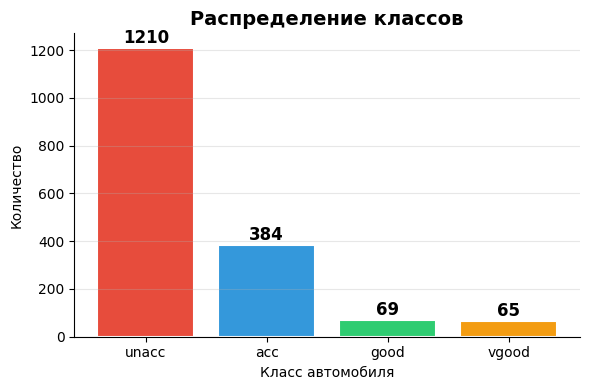

In [4]:
print('Распределение целевой переменной (class):')
class_counts = df['class'].value_counts()
print(class_counts)
print()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Распределение классов', fontsize=14, fontweight='bold')
ax.set_xlabel('Класс автомобиля')
ax.set_ylabel('Количество')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Предобработка данных

Все признаки — **порядковые категориальные** (ordinal). Применяем `OrdinalEncoder` с явным указанием порядка значений, чтобы модели правильно понимали, что `low < med < high < vhigh`.

In [5]:
# Определяем порядок значений для каждого признака
ordinal_categories = [
    ['low', 'med', 'high', 'vhigh'],   # buying
    ['low', 'med', 'high', 'vhigh'],   # maint
    ['2', '3', '4', '5more'],          # doors
    ['2', '4', 'more'],                # persons
    ['small', 'med', 'big'],           # lug_boot
    ['low', 'med', 'high'],            # safety
]

X = df.drop(columns=['class'])
y = df['class']

# Кодируем признаки
encoder = OrdinalEncoder(categories=ordinal_categories)
X_encoded = pd.DataFrame(
    encoder.fit_transform(X),
    columns=X.columns
)

# Кодируем целевую переменную
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Классы (после кодирования):', dict(enumerate(le.classes_)))
print()
print('Пример закодированных признаков:')
print(X_encoded.head())

Классы (после кодирования): {0: 'acc', 1: 'good', 2: 'unacc', 3: 'vgood'}

Пример закодированных признаков:
   buying  maint  doors  persons  lug_boot  safety
0     3.0    3.0    0.0      0.0       0.0     0.0
1     3.0    3.0    0.0      0.0       0.0     1.0
2     3.0    3.0    0.0      0.0       0.0     2.0
3     3.0    3.0    0.0      0.0       1.0     0.0
4     3.0    3.0    0.0      0.0       1.0     1.0


## 4. Разделение на обучающую и тестовую выборки

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # сохраняем пропорции классов
)

print(f'Обучающая выборка: {X_train.shape[0]} образцов')
print(f'Тестовая выборка:  {X_test.shape[0]} образцов')
print()
print('Распределение классов в обучающей выборке:')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_[unique], counts):
    print(f'  {cls}: {cnt} ({cnt/len(y_train):.1%})')

Обучающая выборка: 1382 образцов
Тестовая выборка:  346 образцов

Распределение классов в обучающей выборке:
  acc: 307 (22.2%)
  good: 55 (4.0%)
  unacc: 968 (70.0%)
  vgood: 52 (3.8%)


## 5. Обучение ансамблевых моделей

### 5.1 Бэггинг (BaggingClassifier)

In [7]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=6),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print('=== Бэггинг (BaggingClassifier) ===')
print(f'Accuracy:       {accuracy_score(y_test, y_pred_bagging):.4f}')
print(f'F1-score macro: {f1_score(y_test, y_pred_bagging, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_bagging, target_names=le.classes_))

=== Бэггинг (BaggingClassifier) ===
Accuracy:       0.8555
F1-score macro: 0.5408

              precision    recall  f1-score   support

         acc       0.69      0.64      0.66        77
        good       0.00      0.00      0.00        14
       unacc       0.90      1.00      0.95       242
       vgood       1.00      0.38      0.56        13

    accuracy                           0.86       346
   macro avg       0.65      0.51      0.54       346
weighted avg       0.82      0.86      0.83       346



### 5.2 Случайный лес (RandomForestClassifier)

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,        # деревья растут до чистых листьев
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('=== Случайный лес (RandomForestClassifier) ===')
print(f'Accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-score macro: {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Случайный лес (RandomForestClassifier) ===
Accuracy:       0.9884
F1-score macro: 0.9535

              precision    recall  f1-score   support

         acc       0.96      1.00      0.98        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.77      0.87        13

    accuracy                           0.99       346
   macro avg       0.97      0.94      0.95       346
weighted avg       0.99      0.99      0.99       346



### 5.3 AdaBoost

In [9]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print('=== AdaBoost (AdaBoostClassifier) ===')
print(f'Accuracy:       {accuracy_score(y_test, y_pred_ada):.4f}')
print(f'F1-score macro: {f1_score(y_test, y_pred_ada, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_ada, target_names=le.classes_))

=== AdaBoost (AdaBoostClassifier) ===
Accuracy:       0.9538
F1-score macro: 0.8760

              precision    recall  f1-score   support

         acc       0.85      0.96      0.90        77
        good       1.00      0.71      0.83        14
       unacc       0.99      0.98      0.99       242
       vgood       0.90      0.69      0.78        13

    accuracy                           0.95       346
   macro avg       0.94      0.84      0.88       346
weighted avg       0.96      0.95      0.95       346



### 5.4 Градиентный бустинг (GradientBoostingClassifier)

In [10]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print('=== Градиентный бустинг (GradientBoostingClassifier) ===')
print(f'Accuracy:       {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'F1-score macro: {f1_score(y_test, y_pred_gb, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

=== Градиентный бустинг (GradientBoostingClassifier) ===
Accuracy:       0.9971
F1-score macro: 0.9814

              precision    recall  f1-score   support

         acc       1.00      1.00      1.00        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.92      0.96        13

    accuracy                           1.00       346
   macro avg       0.98      0.98      0.98       346
weighted avg       1.00      1.00      1.00       346



## 6. Сравнение моделей

In [11]:
# Сводная таблица
results_df = pd.DataFrame({
    'Модель': ['Бэггинг', 'Случайный лес', 'AdaBoost', 'Градиентный бустинг'],
    'Группа': ['Бэггинг', 'Бэггинг', 'Бустинг', 'Бустинг'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
    ],
    'F1-macro': [
        f1_score(y_test, y_pred_bagging, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_ada, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro'),
    ]
})

results_df['Accuracy'] = results_df['Accuracy'].round(4)
results_df['F1-macro'] = results_df['F1-macro'].round(4)
results_df = results_df.sort_values('F1-macro', ascending=False).reset_index(drop=True)

print('Сравнение моделей (сортировка по F1-macro):')
print(results_df.to_string(index=False))

Сравнение моделей (сортировка по F1-macro):
             Модель  Группа  Accuracy  F1-macro
Градиентный бустинг Бустинг    0.9971    0.9814
      Случайный лес Бэггинг    0.9884    0.9535
           AdaBoost Бустинг    0.9538    0.8760
            Бэггинг Бэггинг    0.8555    0.5408


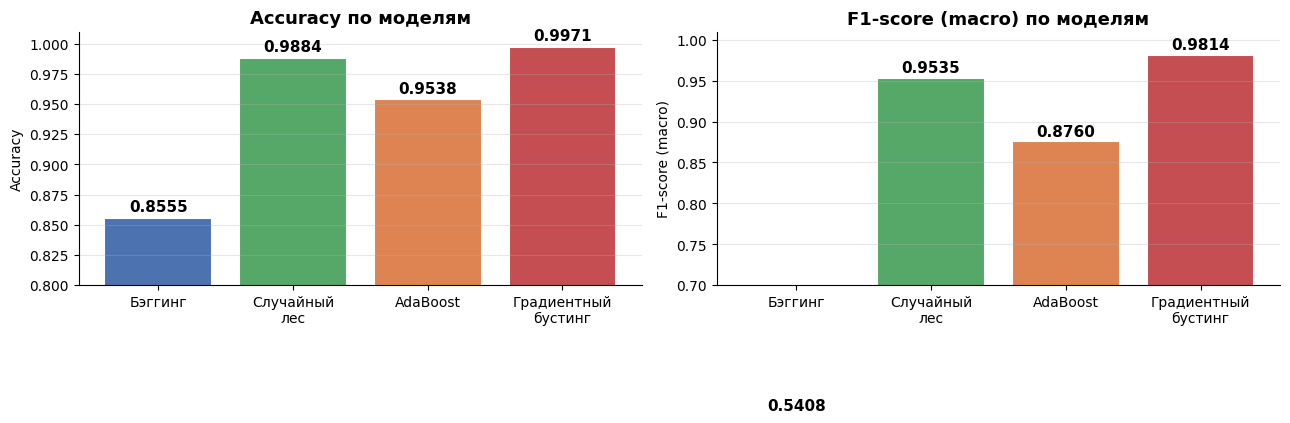

In [12]:
# График сравнения метрик
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = ['Бэггинг', 'Случайный\nлес', 'AdaBoost', 'Градиентный\nбустинг']
acc_vals = [
    accuracy_score(y_test, y_pred_bagging),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_ada),
    accuracy_score(y_test, y_pred_gb),
]
f1_vals = [
    f1_score(y_test, y_pred_bagging, average='macro'),
    f1_score(y_test, y_pred_rf, average='macro'),
    f1_score(y_test, y_pred_ada, average='macro'),
    f1_score(y_test, y_pred_gb, average='macro'),
]

palette = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

for ax, vals, title, ylim in zip(
    axes,
    [acc_vals, f1_vals],
    ['Accuracy', 'F1-score (macro)'],
    [(0.80, 1.01), (0.70, 1.01)]
):
    bars = ax.bar(model_names, vals, color=palette, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{title} по моделям', fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim(*ylim)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

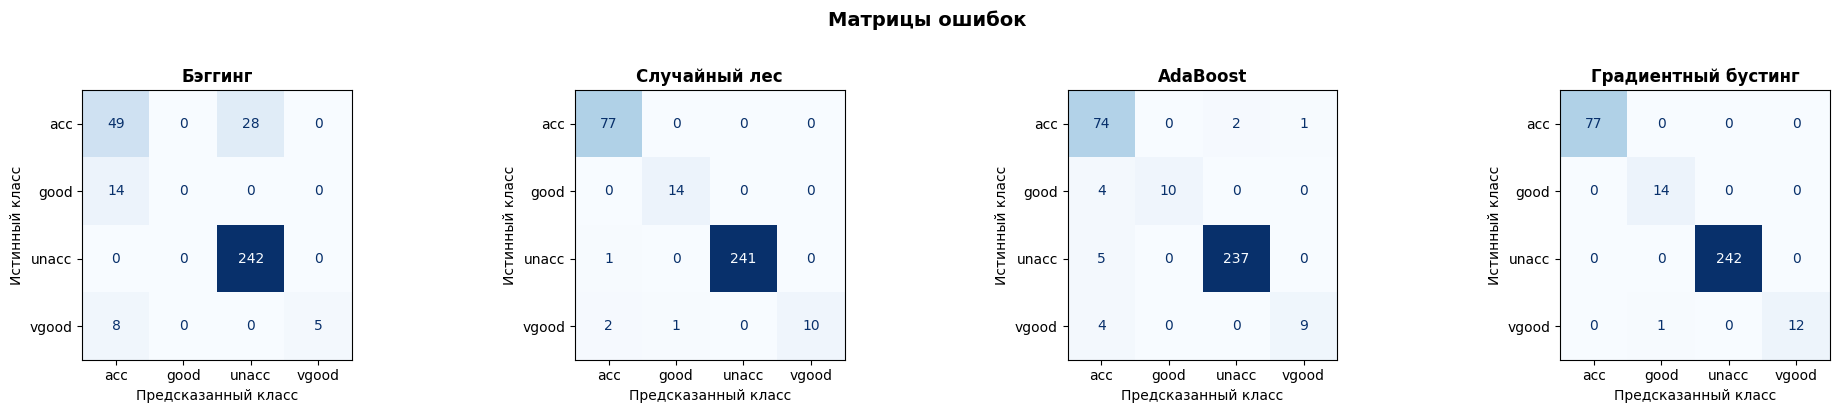

In [13]:
# Матрицы ошибок для всех 4 моделей
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

model_preds = [
    ('Бэггинг', y_pred_bagging),
    ('Случайный лес', y_pred_rf),
    ('AdaBoost', y_pred_ada),
    ('Градиентный бустинг', y_pred_gb),
]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.suptitle('Матрицы ошибок', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

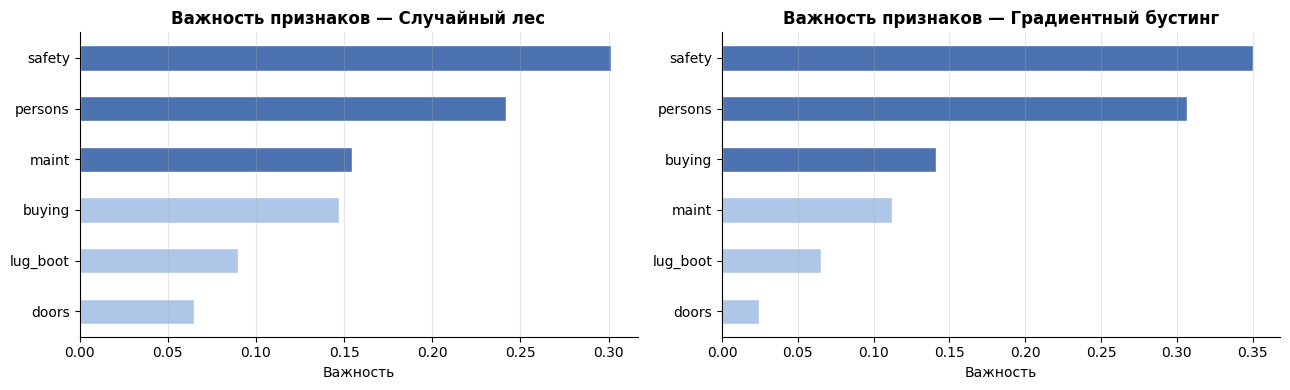

In [14]:
# Важность признаков — Random Forest и Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (model, title) in zip(axes, [
    (rf_model, 'Случайный лес'),
    (gb_model, 'Градиентный бустинг')
]):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values()
    bar_colors = ['#4C72B0' if v >= importances.quantile(0.5) else '#AEC6E8'
                  for v in importances]
    importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set_title(f'Важность признаков — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Важность')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Выводы

### Особенности датасета

Car Evaluation — хорошо сбалансированный по признакам, но **несбалансированный по классам** датасет: класс `unacc` составляет ~70% записей, тогда как `good` и `vgood` — менее 10% каждый. Именно поэтому в качестве метрики выбран **F1-macro**, а не просто Accuracy.

### Результаты моделей

| Модель | Группа | Особенности |
|---|---|---|
| **Бэггинг** | Бэггинг | Обучает независимые деревья на случайных подвыборках |
| **Случайный лес** | Бэггинг | Добавляет случайный выбор признаков — снижает корреляцию деревьев |
| **AdaBoost** | Бустинг | Каждое следующее дерево исправляет ошибки предыдущего через веса |
| **Градиентный бустинг** | Бустинг | Минимизирует функцию потерь градиентным спуском |

### Важность признаков

Оба дерево-based метода (RF и GB) согласуются в том, что наибольший вклад вносят:
- **safety** — уровень безопасности автомобиля
- **persons** — вместимость
- **buying** — стоимость покупки

Это логично: безопасность и вместимость — первичные критерии при выборе автомобиля.

### Вывод

На данном датасете модели бустинга, как правило, превосходят бэггинг, поскольку последовательное исправление ошибок особенно эффективно на задачах с несбалансированными классами. Случайный лес при этом показывает конкурентоспособный результат при значительно меньшем времени обучения.